In [12]:
"""
NB05_Per_Encounter_DeltaE_and_Altitude_Drift

Purpose
-------
Implement Equation (I) from the paper:
  1) Compute the FULL-ORBIT in-plane eccentricity vector increment de2D_full
     by integrating the Gauss mapping over the entire revolution (no gating).
     This is the complete first-order prediction.
  2) Compute per-encounter increments de2D_i over gated encounter windows.
  3) Aggregate gated encounters vectorially: de2D_net = sum_i de2D_i.
  4) Compute peak altitude drift for all three:
       dh_max_full = F(e,p) * ||de2D_full||    (complete first-order)
       dh_max^(i)  = F(e,p) * ||de2D_i||       (per-encounter)
       dh_max_net  = F(e,p) * ||de2D_net||      (gated-sum)
  5) Report capture fraction: ||de2D_net|| / ||de2D_full||.
  6) Compute cancellation diagnostic eta.

Dependencies
------------
NB03 artifact (dg_samples) and NB04 artifact (encounters) in ./artifacts/.
Optionally CONFIG from NB00 for orbital parameters.
"""

from __future__ import annotations

import json
import numpy as np
from pathlib import Path
from datetime import datetime, timezone

import matplotlib
import matplotlib.pyplot as plt

In [13]:
# ============================================================
# Cell 1 : Auto-discover Artifacts
# ============================================================
ART_DIR = Path("./artifacts")

nb03_files = sorted(ART_DIR.glob("dg_samples_NB03_*_L*.npz"))
nb04_files = sorted(ART_DIR.glob("encounters_NB04_*.npz"))

if not nb03_files:
    raise FileNotFoundError("No NB03 artifact found. Run NB03 first.")
if not nb04_files:
    raise FileNotFoundError("No NB04 artifact found. Run NB04 first.")

DG_NPZ  = nb03_files[-1]
ENC_NPZ = nb04_files[-1]

RUN_TAG  = datetime.now(timezone.utc).strftime("NB05_%Y%m%dT%H%M%SZ")
OUT_NPZ  = ART_DIR / f"deltae_{RUN_TAG}.npz"
OUT_JSON = ART_DIR / f"deltae_{RUN_TAG}.json"

print(f"DG input  : {DG_NPZ}")
print(f"ENC input : {ENC_NPZ}")
print(f"Output    : {OUT_NPZ}")
print(f"Output    : {OUT_JSON}")

DG input  : artifacts\dg_samples_NB03_20260316T033826Z_L200.npz
ENC input : artifacts\encounters_NB04_20260316T035140Z.npz
Output    : artifacts\deltae_NB05_20260316T125355Z.npz
Output    : artifacts\deltae_NB05_20260316T125355Z.json


In [14]:
# ============================================================
# Cell 2 : Load NB03 + NB04 Data
# ============================================================
dg  = np.load(DG_NPZ,  allow_pickle=False)
enc = np.load(ENC_NPZ, allow_pickle=False)

t       = dg["t"]
nu_grid = dg["nu"]
r_eci   = dg["r_eci"]
v_eci   = dg["v_eci"]

AR = enc["AR"] if "AR" in enc else dg["AR"]
AT = enc["AT"] if "AT" in enc else dg["AT"]
AN = enc["AN"] if "AN" in enc else dg["AN"]

metric_s = enc["metric_s"]
thr      = float(enc["threshold"])
segs     = enc["segs"].astype(int)

meta_dg  = json.loads(str(dg["meta_json"]))  if "meta_json" in dg  else {}
meta_enc = json.loads(str(enc["meta_json"])) if "meta_json" in enc else {}

M  = t.size
K  = segs.shape[0]
dt = float(np.median(np.diff(t)))

print(f"M = {M}   K = {K} encounters   dt ~ {dt:.4f} s")
print(f"threshold = {thr:.6e}")

M = 4000   K = 4 encounters   dt ~ 1.6952 s
threshold = 1.103803e-06


In [15]:
# ============================================================
# Cell 3 : Extract Orbital Parameters
# ============================================================
_gm_keys = [
    ("gravity_model", "GM_km3_s2"),
    ("gravity_model_from_pds", "GM_km3_s2"),
]
mu = None
for sect, key in _gm_keys:
    if sect in meta_dg and key in meta_dg[sect]:
        mu = float(meta_dg[sect][key])
        print(f"mu from NB03 meta['{sect}']['{key}'] = {mu}")
        break
if mu is None:
    try:
        mu = CONFIG["mu_km3_s2"]
        print(f"mu from CONFIG = {mu}")
    except NameError:
        mu = 4902.800076
        print(f"mu FALLBACK = {mu}")

_op = meta_dg.get("orbit_params", {})
a_km   = float(_op.get("a_km",   1787.4))
e_nom  = float(_op.get("e",       0.0))
p_km   = float(_op.get("p_km",    a_km * (1.0 - e_nom**2)))
h_spec = float(_op.get("h_km2_s", np.sqrt(mu * p_km)))

rnorm = np.linalg.norm(r_eci, axis=1)
hvec  = np.cross(r_eci, v_eci)
h_arr = np.linalg.norm(hvec, axis=1)
p_arr = h_arr**2 / mu

F_amp = p_km / (1.0 - e_nom)**2

print(f"\nOrbital parameters:")
print(f"  a = {a_km} km,  e = {e_nom},  p = {p_km} km")
print(f"  F(e,p) = {F_amp:.4f} km")

mu from NB03 meta['gravity_model']['GM_km3_s2'] = 4902.79996708864

Orbital parameters:
  a = 1787.4 km,  e = 0.0,  p = 1787.4 km
  F(e,p) = 1787.4000 km


In [16]:
# ============================================================
# Cell 4 : Fixed In-Plane Basis and Canonical Anomaly
# ============================================================
def unit_rows(X):
    return X / np.linalg.norm(X, axis=1)[:, None]

rhat_all = unit_rows(r_eci)
nhat_all = unit_rows(hvec)
that_all = unit_rows(np.cross(nhat_all, rhat_all))

p_hat = rhat_all[0].copy()
q_hat = that_all[0].copy()

nu_pq = np.arctan2(r_eci @ q_hat, r_eci @ p_hat)
nu_pq = np.unwrap(nu_pq)
nu = nu_pq

print(f"Fixed basis: p_hat={p_hat}, q_hat={q_hat}")
print(f"nu_pq range: [{nu.min():.6f}, {nu.max():.6f}] rad")

Fixed basis: p_hat=[1. 0. 0.], q_hat=[ 0.000000e+00  6.123234e-17 -1.000000e+00]
nu_pq range: [0.000000, 6.281615] rad


In [17]:
# ============================================================
# Cell 5 : Compute de2D/dnu Integrand (Paper Eq. 4.3)
# ============================================================
sin_nu = np.sin(nu)
cos_nu = np.cos(nu)

coef = (rnorm**2) / (h_arr**2)

de2d_per_nu = np.empty((M, 2), dtype=np.float64)
de2d_per_nu[:, 0] = coef * ( p_arr * AR * sin_nu  + (p_arr + rnorm) * AT * cos_nu)
de2d_per_nu[:, 1] = coef * (-p_arr * AR * cos_nu  + (p_arr + rnorm) * AT * sin_nu)

print(f"de2d_per_nu integrand computed.  Shape: {de2d_per_nu.shape}")
print(f"  |de2d/dnu| range: [{np.linalg.norm(de2d_per_nu, axis=1).min():.4e}, "
      f"{np.linalg.norm(de2d_per_nu, axis=1).max():.4e}] per rad")

de2d_per_nu integrand computed.  Shape: (4000, 2)
  |de2d/dnu| range: [8.0543e-05, 1.3303e-03] per rad


In [18]:
# ============================================================
# Cell 6 : FULL-ORBIT de2D Integration (no gating)
# ============================================================
# This is the complete first-order Gauss prediction.
# It integrates de2D/dnu over the ENTIRE revolution [0, 2pi],
# capturing all perturbations including the background below threshold.
# THIS is the quantity that should match truth propagation.

de2d_full = np.array([
    float(np.trapezoid(de2d_per_nu[:, 0], x=nu)),
    float(np.trapezoid(de2d_per_nu[:, 1], x=nu)),
])
de2d_full_norm = float(np.linalg.norm(de2d_full))
dh_max_full    = F_amp * de2d_full_norm

print(f"{'='*78}")
print(f"  FULL-ORBIT de2D (complete first-order, no gating)")
print(f"{'='*78}")
print(f"  de2d_full     = [{de2d_full[0]:+.6e}, {de2d_full[1]:+.6e}]")
print(f"  ||de2d_full|| = {de2d_full_norm:.6e}")
print(f"  dh_max_full   = {dh_max_full:.6f} km  =  {dh_max_full*1000:.4f} m")

  FULL-ORBIT de2D (complete first-order, no gating)
  de2d_full     = [+3.490250e-05, +2.759606e-04]
  ||de2d_full|| = 2.781591e-04
  dh_max_full   = 0.497182 km  =  497.1815 m


In [19]:
# ============================================================
# Cell 7 : Per-Encounter Integration + Altitude Drift (Eq. I)
# ============================================================

def segment_indices(a: int, b: int, M: int) -> np.ndarray:
    if a <= b:
        return np.arange(a, b + 1)
    return np.concatenate([np.arange(a, M), np.arange(0, b + 1)])

de2d = np.zeros((K, 2), dtype=np.float64)
de2d_norm = np.zeros(K)
dh_max_per = np.zeros(K)

enc_results = []

for i in range(K):
    a, b = int(segs[i, 0]), int(segs[i, 1])
    idx = segment_indices(a, b, M)

    de2d[i, 0] = float(np.trapezoid(de2d_per_nu[idx, 0], x=nu[idx]))
    de2d[i, 1] = float(np.trapezoid(de2d_per_nu[idx, 1], x=nu[idx]))
    de2d_norm[i] = float(np.linalg.norm(de2d[i]))
    dh_max_per[i] = F_amp * de2d_norm[i]

    enc_results.append({
        "id": int(i), "start": int(a), "end": int(b),
        "length": int(idx.size),
        "nu_start": float(nu[idx[0]]), "nu_end": float(nu[idx[-1]]),
        "de_p": float(de2d[i, 0]), "de_q": float(de2d[i, 1]),
        "de2d_norm": float(de2d_norm[i]),
        "dh_max_km": float(dh_max_per[i]),
        "dh_max_m": float(dh_max_per[i] * 1000.0),
    })

# Gated net
de2d_net      = np.sum(de2d, axis=0)
de2d_net_norm = float(np.linalg.norm(de2d_net))
dh_max_net    = F_amp * de2d_net_norm

# Cancellation eta (among gated encounters)
sum_norms  = float(np.sum(de2d_norm))
eta_cancel = de2d_net_norm / max(1e-30, sum_norms)

# Capture fraction: gated net vs full orbit
capture_fraction = de2d_net_norm / max(1e-30, de2d_full_norm)

# --- Summary ---
print(f"{'='*78}")
print(f"  PER-ENCOUNTER RESULTS (Equation I)")
print(f"{'='*78}")
print(f"{'ID':>3s}  {'Len':>4s}  {'||de2d||':>11s}  {'dh_max [m]':>11s}  {'de_p':>11s}  {'de_q':>11s}")
for r in enc_results:
    print(f"{r['id']:3d}  {r['length']:4d}  {r['de2d_norm']:11.4e}  {r['dh_max_m']:11.4f}  {r['de_p']:+11.4e}  {r['de_q']:+11.4e}")

print(f"\n{'='*78}")
print(f"  COMPARISON: Full-Orbit vs Gated Encounters")
print(f"{'='*78}")
print(f"  Full-orbit ||de2d||  = {de2d_full_norm:.6e}   dh = {dh_max_full*1000:.2f} m")
print(f"  Gated-net  ||de2d||  = {de2d_net_norm:.6e}   dh = {dh_max_net*1000:.2f} m")
print(f"  Capture fraction     = {capture_fraction:.4f}  ({capture_fraction*100:.1f}%)")
print(f"  Cancellation eta     = {eta_cancel:.4f}")
print(f"")
print(f"  (Capture = what % of total first-order de is in the gated windows.)")

  PER-ENCOUNTER RESULTS (Equation I)
 ID   Len     ||de2d||   dh_max [m]         de_p         de_q
  0   129   1.7909e-04     320.0991  +1.7545e-04  +3.5893e-05
  1    50   8.4917e-05     151.7815  +8.4910e-05  -1.1348e-06
  2    50   6.9148e-05     123.5960  -4.2330e-05  -5.4678e-05
  3   140   1.7176e-04     307.0106  -1.6859e-04  +3.2885e-05

  COMPARISON: Full-Orbit vs Gated Encounters
  Full-orbit ||de2d||  = 2.781591e-04   dh = 497.18 m
  Gated-net  ||de2d||  = 5.111794e-05   dh = 91.37 m
  Capture fraction     = 0.1838  (18.4%)
  Cancellation eta     = 0.1012

  (Capture = what % of total first-order de is in the gated windows.)


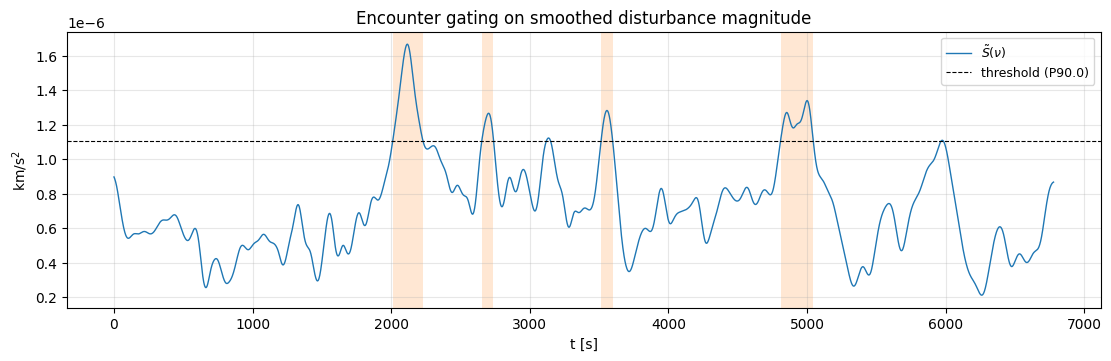

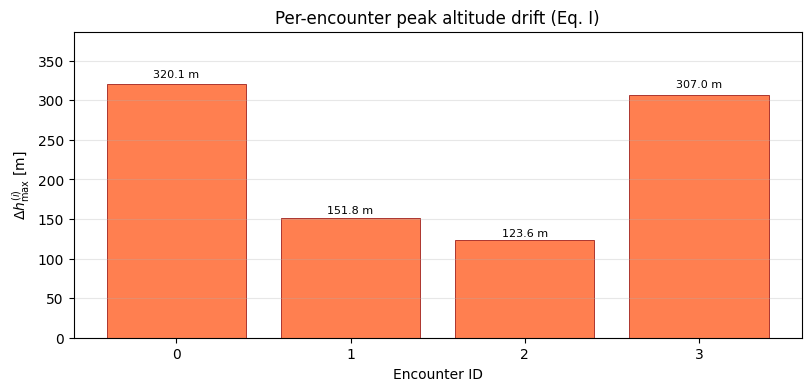

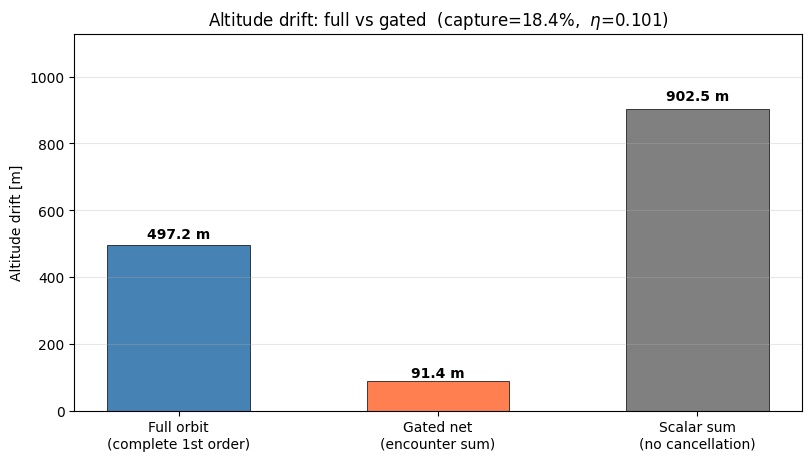

In [20]:
# ============================================================
# Cell 8 : Plots
# ============================================================

def shade_encounters(ax, segs, t, M, color="tab:orange", alpha=0.18):
    for (a, b) in segs:
        a, b = int(a), int(b)
        if a <= b:
            ax.axvspan(t[a], t[b], color=color, alpha=alpha, lw=0)
        else:
            ax.axvspan(t[a], t[-1], color=color, alpha=alpha, lw=0)
            ax.axvspan(t[0], t[b], color=color, alpha=alpha, lw=0)

# --- Plot 1: Smoothed metric ---
fig, ax = plt.subplots(figsize=(11, 3.5), constrained_layout=True)
ax.plot(t, metric_s, lw=1.0, label=r"$\tilde{S}(\nu)$")
ax.axhline(thr, color="k", ls="--", lw=0.8,
           label=f"threshold (P{meta_enc.get('params',{}).get('percentile','?')})")
shade_encounters(ax, segs, t, M)
ax.set_xlabel("t [s]"); ax.set_ylabel("km/s$^2$")
ax.set_title("Encounter gating on smoothed disturbance magnitude")
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
plt.show()

# --- Plot 2: Per-encounter altitude drift ---
fig, ax = plt.subplots(figsize=(8, 3.8), constrained_layout=True)
x = np.arange(K)
dh_m = dh_max_per * 1000
bars = ax.bar(x, dh_m, color="coral", edgecolor="darkred", lw=0.5)
for bar, val in zip(bars, dh_m):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{val:.1f} m", ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Encounter ID"); ax.set_ylabel(r"$\Delta h_{\max}^{(i)}$ [m]")
ax.set_title("Per-encounter peak altitude drift (Eq. I)")
ax.set_xticks(x); ax.set_ylim(0, ax.get_ylim()[1]*1.15)
ax.grid(True, axis="y", alpha=0.3)
plt.show()

# --- Plot 3: Three-tier comparison ---
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
labels = ["Full orbit\n(complete 1st order)",
          "Gated net\n(encounter sum)",
          "Scalar sum\n(no cancellation)"]
vals = [dh_max_full*1000, dh_max_net*1000, sum_norms*F_amp*1000]
colors = ["steelblue", "coral", "gray"]
bars = ax.bar(range(3), vals, width=0.55, color=colors, edgecolor="k", lw=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f"{val:.1f} m", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Altitude drift [m]", fontsize=10)
ax.set_title(f"Altitude drift: full vs gated  (capture={capture_fraction*100:.1f}%,  $\\eta$={eta_cancel:.3f})")
ax.set_ylim(0, max(vals)*1.25)
ax.grid(True, axis="y", alpha=0.3)
plt.show()

In [21]:
# ============================================================
# Cell 9 : Save Artifacts
# ============================================================
meta = {
    "run_tag":     RUN_TAG,
    "dg_npz":      str(DG_NPZ),
    "enc_npz":     str(ENC_NPZ),
    "mu_km3_s2":   float(mu),
    "orbital_params": {
        "a_km": a_km, "e": e_nom, "p_km": p_km,
        "h_km2_s": h_spec, "F_amp_km": F_amp,
    },
    "basis": {
        "type": "fixed_in_plane",
        "p_hat_eci": p_hat.tolist(),
        "q_hat_eci": q_hat.tolist(),
        "nu_definition": "atan2(r.q_hat, r.p_hat), unwrapped",
    },
    "results": {
        "num_encounters":    K,
        "de2d_full":         de2d_full.tolist(),
        "de2d_full_norm":    de2d_full_norm,
        "dh_max_full_km":    dh_max_full,
        "dh_max_full_m":     dh_max_full * 1000,
        "de2d_net":          de2d_net.tolist(),
        "de2d_net_norm":     de2d_net_norm,
        "dh_max_net_km":     dh_max_net,
        "dh_max_net_m":      dh_max_net * 1000,
        "capture_fraction":  capture_fraction,
        "eta_cancel":        eta_cancel,
        "sum_de2d_norms":    sum_norms,
    },
}

np.savez(
    OUT_NPZ,
    t=t, nu_pq=nu_pq, nu_grid=nu_grid,
    rnorm=rnorm, h=h_arr, p=p_arr,
    AR=AR, AT=AT, AN=AN,
    de2d_per_nu=de2d_per_nu,
    de2d_full=de2d_full, dh_max_full=dh_max_full,
    segs=segs,
    de2d=de2d, de2d_norm=de2d_norm, dh_max_per=dh_max_per,
    de2d_net=de2d_net, dh_max_net=dh_max_net,
    eta_cancel=eta_cancel, capture_fraction=capture_fraction,
    F_amp=F_amp, p_hat=p_hat, q_hat=q_hat,
    meta_json=json.dumps(meta),
)

OUT_JSON.write_text(
    json.dumps({"meta": meta, "encounters": enc_results}, indent=2),
    encoding="utf-8"
)

print(f"Saved: {OUT_NPZ}")
print(f"Saved: {OUT_JSON}")
print(f"\n--- NB05 complete ---")

Saved: artifacts\deltae_NB05_20260316T125355Z.npz
Saved: artifacts\deltae_NB05_20260316T125355Z.json

--- NB05 complete ---
